# Lab 3 — Two Moons Classification

Lab 1 and Lab 2 trained on the 4-point AND/XOR gates. This lab trains the same
kind of hidden-layer network — `2 inputs -> 8 hidden (sigmoid) -> 1 output
(sigmoid)` — on the two-moons dataset (`two_moons_train.csv` /
`two_moons_val.csv`): 700 training points and 300 validation points arranged
in two interleaved crescents. It then shows the model's predictions both as
per-point numbers and as a decision boundary dividing the crescents.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np

from numpy_nn import ACTIVATIONS, COSTS, Layer, Network, random_weights, zero_bias
from numpy_trainer import DataLoader, Trainer, plot_decision_boundary, plot_history, print_predictions
import matplotlib.pyplot as plt

LEARNING_RATE = 0.7
EPOCHS = 500


def load_two_moons(path):
    data = np.loadtxt(path, delimiter=",")
    return data[:, :2], data[:, 2:]


train_inputs, train_targets = load_two_moons(REPO_ROOT / "lab3" / "two_moons_train.csv")
val_inputs, val_targets = load_two_moons(REPO_ROOT / "lab3" / "two_moons_val.csv")
len(train_inputs), len(val_inputs)

(700, 300)

## Training

The validation set is passed to the trainer, which evaluates it after every epoch without
training on it.

In [2]:
np.random.seed(1)

hidden_layer = Layer.build(
    input_size=2, output_size=8,
    weight=random_weights(input_size=2, output_size=8), bias=zero_bias(8),
    activation=ACTIVATIONS.SIGMOID,
)
output_layer = Layer.build(
    input_size=8, output_size=1,
    weight=random_weights(input_size=8, output_size=1), bias=zero_bias(1),
    activation=ACTIVATIONS.SIGMOID,
)
moons_network = Network(hidden_layer, output_layer)

moons_trainer = Trainer(moons_network, cost=COSTS.MSE, learning_rate=LEARNING_RATE)
moons_trainer.train(
    DataLoader(train_inputs, train_targets, batch_size=1, shuffle=False),
    epochs=EPOCHS,
    validation=(val_inputs, val_targets),
    print_interval=100,
);

epoch  100 | loss: 0.0028 | accuracy: 99.71% | val loss: 0.0079 | val accuracy: 99.00%


epoch  200 | loss: 0.0016 | accuracy: 99.86% | val loss: 0.0071 | val accuracy: 99.33%


epoch  300 | loss: 0.0002 | accuracy: 100.00% | val loss: 0.0084 | val accuracy: 99.00%


epoch  400 | loss: 0.0001 | accuracy: 100.00% | val loss: 0.0085 | val accuracy: 99.00%


epoch  500 | loss: 0.0001 | accuracy: 100.00% | val loss: 0.0086 | val accuracy: 99.00%


## Training history

Loss and accuracy per epoch for both the training set and the validation set.

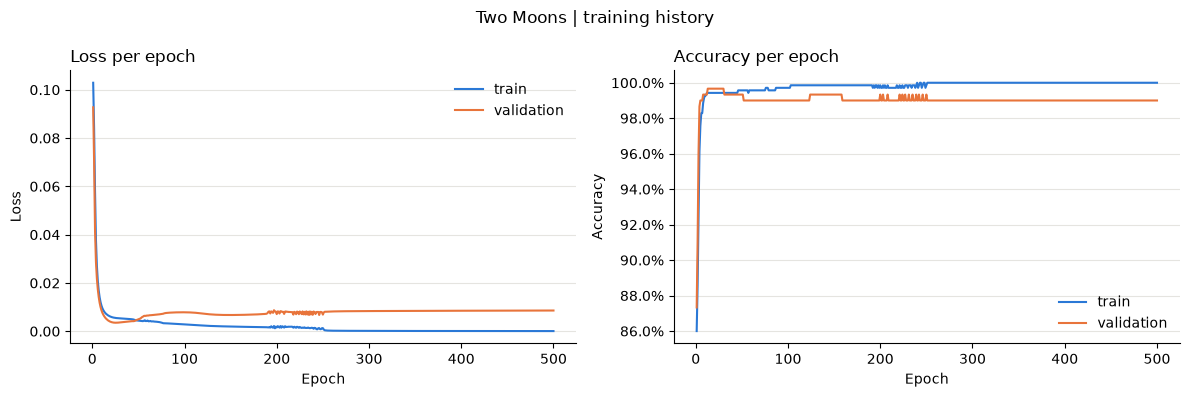

In [3]:
plot_history(moons_trainer.history, title="Two Moons | training history")

## Predictions

With 700/300 points, printing every prediction isn't useful, so this shows
the cost and accuracy over the full train/val sets plus a handful of individual
validation predictions.

In [4]:
train_loss, train_accuracy = moons_trainer.evaluate(train_inputs, train_targets)
val_loss, val_accuracy = moons_trainer.evaluate(val_inputs, val_targets)

print(f"train ({len(train_inputs)} points) | loss: {train_loss:.4f} | accuracy: {train_accuracy:.2%}")
print(f"val   ({len(val_inputs)} points) | loss: {val_loss:.4f} | accuracy: {val_accuracy:.2%}")

train (700 points) | loss: 0.0001 | accuracy: 100.00%
val   (300 points) | loss: 0.0086 | accuracy: 99.00%


In [5]:
print("sample validation predictions:")
print_predictions(val_inputs[:10], val_targets[:10], moons_network.forward(val_inputs[:10]))

sample validation predictions:
inputs: [-0.0261, -1.0049] | target: [1.0000] | prediction: [0.9962]
inputs: [1.3053, -0.8260] | target: [1.0000] | prediction: [0.9996]
inputs: [1.7595, 0.2491] | target: [1.0000] | prediction: [1.0000]
inputs: [0.0386, 1.4773] | target: [0.0000] | prediction: [0.0000]
inputs: [0.6050, -1.9715] | target: [1.0000] | prediction: [1.0000]
inputs: [1.0348, -0.9287] | target: [1.0000] | prediction: [0.9994]
inputs: [0.8970, -1.4277] | target: [1.0000] | prediction: [0.9995]
inputs: [-1.0685, 1.3449] | target: [0.0000] | prediction: [0.0003]
inputs: [-0.2716, -1.3415] | target: [1.0000] | prediction: [0.9947]
inputs: [-0.0643, -1.1114] | target: [1.0000] | prediction: [0.9962]


## Decision boundary

The predicted regions across the whole input plane — the boundary line dividing the two
crescents — with any misclassified points circled in red.

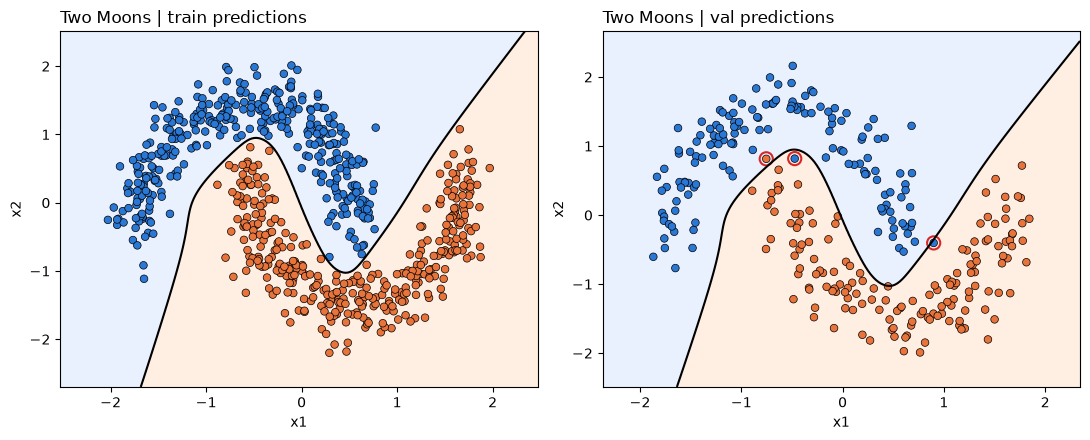

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
plot_decision_boundary(moons_network, train_inputs, train_targets, title="Two Moons | train predictions", ax=axes[0])
plot_decision_boundary(moons_network, val_inputs, val_targets, title="Two Moons | val predictions", ax=axes[1])
fig.tight_layout()
plt.show()

## Takeaway

Eight sigmoid hidden units are enough to bend the boundary around both crescents: the network
fits all 700 training points and gets 297 of the 300 unseen validation points right (99.00%). The
three mistakes sit right on the boundary, where the two crescents come closest.

Validation loss is lowest at epoch 26 (0.0035, 99.67% accuracy) and slowly rises afterwards
while training loss keeps falling to zero — the network starts memorising the training points,
a mild case of overfitting. Stopping on the best validation epoch would be the natural next step.